In [1]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.datasets import mnist

In [5]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [6]:
X_train.shape

(60000, 28, 28)

In [7]:
X_train[0].shape

(28, 28)

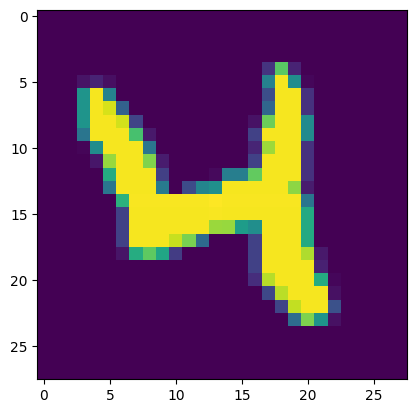

In [13]:
import matplotlib.pyplot as plt

plt.imshow(X_train[20])

In [14]:
X_train = X_train/255
X_test = X_test/255

In [15]:
model = Sequential()

model.add(Input(shape = (28,28)))
model.add(Flatten())
model.add(Dense(128, activation = "relu"))
model.add(Dense(10, activation = "softmax"))

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(optimizer = "adam", loss = "sparse_categorical_crossentropy", metrics = ["accuracy"])

In [23]:
history = model.fit(X_train, y_train, epochs = 10, validation_split = 0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6809 - loss: 1.3618 - val_accuracy: 0.8374 - val_loss: 0.7186
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8540 - loss: 0.5873 - val_accuracy: 0.8843 - val_loss: 0.4575
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8827 - loss: 0.4396 - val_accuracy: 0.8963 - val_loss: 0.3815
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8954 - loss: 0.3825 - val_accuracy: 0.9065 - val_loss: 0.3413
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9008 - loss: 0.3522 - val_accuracy: 0.9109 - val_loss: 0.3203
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9061 - loss: 0.3329 - val_accuracy: 0.9140 - val_loss: 0.3045
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9097 - loss: 0.3187 - val_accuracy: 0.9162 - val_loss: 0.2942
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9111 - loss: 0.3079 - 

In [24]:
y_prob = model.predict(X_test)
y_prob

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[6.32963856e-05, 1.35936853e-08, 4.16512448e-05, ...,
        9.98268008e-01, 5.44208115e-06, 6.42544881e-04],
       [1.36623462e-03, 1.71330375e-05, 9.84148800e-01, ...,
        5.47199890e-11, 7.41765834e-04, 1.17652388e-09],
       [6.31280545e-06, 9.79167342e-01, 8.78513232e-03, ...,
        3.32901091e-03, 2.32690177e-03, 4.61331831e-04],
       ...,
       [8.93401364e-07, 2.65859489e-06, 2.84835114e-05, ...,
        1.71483844e-03, 1.44573152e-02, 6.49687871e-02],
       [7.64686672e-04, 1.13870672e-04, 4.43148856e-05, ...,
        9.99555232e-06, 1.21700644e-01, 2.82742440e-05],
       [3.36012308e-05, 1.48608400e-11, 1.03710321e-04, ...,
        1.38343004e-10, 4.20726167e-07, 1.02512034e-08]],
      shape=(10000, 10), dtype=float32)

In [26]:
y_pred = y_prob.argmax(axis=1)
y_pred

array([7, 2, 1, ..., 4, 5, 6], shape=(10000,))

In [27]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9192

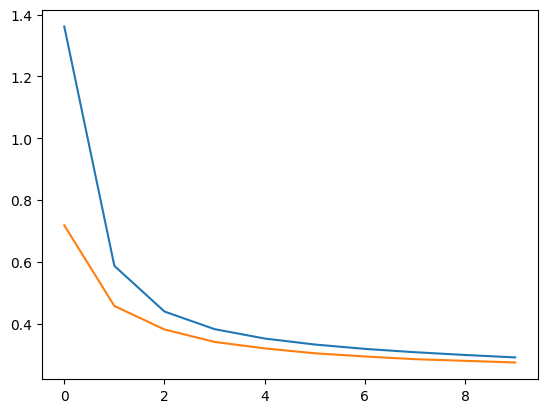

In [28]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

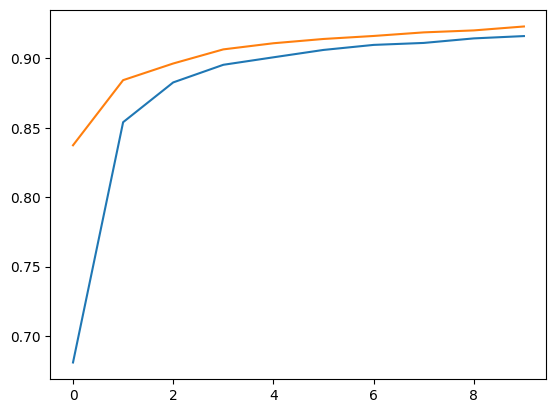

In [29]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

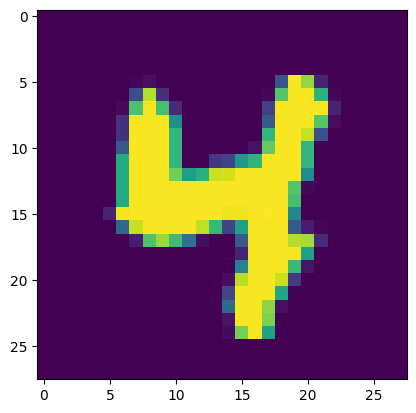

In [34]:
plt.imshow(X_test[85])

In [35]:
model.predict(X_test[85].reshape(1, 28, 28)).argmax(axis = 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


array([4])